# Timerseries Analysis

In [1]:
import librosa
import numpy as np
import pandas as pd
from tslearn.shapelets import LearningShapelets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import glob
from sklearn.cluster import KMeans
from typing import Optional, List, Dict
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from tqdm import tqdm

## Load Audio and Extract Features

Load each file, trim, normalize amplitude, beattrack and then extract features.

In [2]:
def extract_beat_sync_features(
    mp3_path: str,
    sr: int = 22050,
    trim_db: int = 25,
    hop_length: int = 512,
    n_mfcc: int = 13,
) -> dict:
    y, sr = librosa.load(mp3_path, sr=sr, mono=True)
    y, _ = librosa.effects.trim(y, top_db=trim_db)

    # normalize peak amplitude
    peak = np.max(np.abs(y)) + 1e-9
    y = y / peak

    duration = librosa.get_duration(y=y, sr=sr)

    # beat tracking
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    tempo, beat_frames = librosa.beat.beat_track(
        onset_envelope=onset_env, sr=sr, hop_length=hop_length
    )
    if len(beat_frames) < 2:
        # fallback: if beat tracking fails, treat it like one "beat" at start
        beat_frames = np.array([0], dtype=int)

    beat_times = librosa.frames_to_time(
        beat_frames, sr=sr, hop_length=hop_length
    )

    # frame-level features
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length
    )  # (n_mfcc, n_frames)

    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr, hop_length=hop_length
    )  # (12, n_frames)

    # use the same onset envelope as a 1D rhythmic/dynamic feature
    onset = onset_env.reshape(1, -1)  # (1, n_frames)

    # beat-synchronous aggregation (median is robust)
    mfcc_bs = librosa.util.sync(mfcc, beat_frames, aggregate=np.median).T
    chroma_bs = librosa.util.sync(chroma, beat_frames, aggregate=np.median).T
    onset_bs = librosa.util.sync(onset, beat_frames, aggregate=np.median).T

    return {
        "mfcc_bs": mfcc_bs,
        "chroma_bs": chroma_bs,
        "onset_bs": onset_bs,
        "tempo": float(tempo),
        "beat_times": beat_times,
        "duration": float(duration),
    }

features = []
for mp3_path in tqdm(sorted(glob.glob("../dataset/fedez_fibra/*.mp3"))[:20]):
    out = extract_beat_sync_features(mp3_path)
    out["artist"] = mp3_path.split(" ")[0].split("/")[-1]
    features.append(out)

pd.DataFrame(features).head()

  0%|          | 0/20 [00:00<?, ?it/s]/var/folders/xt/8hcc3d6j7l565z9k6z0w88jh0000gn/T/ipykernel_7115/3405016487.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "tempo": float(tempo),
100%|██████████| 20/20 [00:11<00:00,  1.73it/s]


,mfcc_bs,chroma_bs,onset_bs,tempo,beat_times,duration,artist
0,"[[-350.313, 91.51345, 13.632149, 17.825752, 10...","[[0.438727, 0.38372946, 0.24992833, 0.44548976...","[[0.3700195], [0.50319743], [0.61256325], [0.6...",89.102909,"[1.0913378684807256, 1.787936507936508, 2.4613...",119.675646,ART07024718
1,"[[-242.33176, 70.255615, 21.659698, -4.751523,...","[[0.22477466, 0.41218686, 0.20322362, 0.043952...","[[1.5244005], [1.012903], [1.3447756], [1.2036...",123.046875,"[2.507755102040816, 2.995374149659864, 3.50621...",122.694240,ART07024718
2,"[[-59.30338, 49.993156, 17.60097, 12.012684, -...","[[0.33985, 0.34022728, 0.3631826, 0.87398976, ...","[[0.0], [0.84293026], [0.9664582], [1.4517415]...",123.046875,"[0.06965986394557823, 0.5572789115646258, 1.04...",185.527438,ART07024718
3,"[[-52.30634, 85.76688, -3.730764, 64.843124, 3...","[[1.0, 0.8255083, 0.7445236, 0.6228194, 0.4834...","[[0.0], [0.31376678], [0.284397], [0.33596697]...",92.285156,"[0.06965986394557823, 0.8591383219954648, 1.50...",181.998005,ART07024718
4,"[[-142.6217, 22.849413, -68.8163, 13.575657, -...","[[0.3422467, 0.3433115, 0.48477343, 0.82623625...","[[0.0], [0.5330403], [0.54297143], [0.29903427...",129.199219,"[0.06965986394557823, 0.5340589569160997, 0.99...",196.742676,ART07024718


## Feature Aggregation for Clustering

We convert each mp3 into a single fixed-length feature vector by first computing
beat-synchronous audio descriptors and then aggregating them across
the whole track. This gives a tabular dataset suitable for standard clustering
(without DTW or subsequences).

Selected aggregated features per song:

- Basic track/tempo descriptors
  - duration: total length in seconds
  - tempo: estimated BPM from beat tracking
  - n_beats: number of detected beats (rough proxy for song length / beat density)

- MFCC statistics (timbre / production / "color")
  - mfcc_mean_*: mean of each MFCC coefficient across beats
  - mfcc_std_*: standard deviation of each MFCC coefficient across beats
  - mfcc_var_mean: average variance across MFCC coefficients (overall timbre variability)

- Chroma statistics (tonality / harmonic content distribution)
  - chroma_mean_*: average energy for each pitch class (12 dimensions)
  - chroma_std_*: variability of each pitch class across beats
  - chroma_entropy: entropy of the normalized chroma mean vector
    (higher = more evenly spread pitch classes; lower = more dominated by a few)
  - chroma_max_frac: fraction of energy in the most dominant pitch class

- Onset strength statistics (rhythmic density / dynamic “punch”)
  - onset_mean: average and variability of beat-synchronous onset strength
  - onset_std: average and variability of beat-synchronous onset strength
  - onset_p95: 95th percentile (captures strong accent peaks)
  - onset_peakiness: ratio p95 / mean (how “spiky” the accents are)
  - onset_diff_mean: mean / 95th percentile of absolute beat-to-beat
    changes in onset strength (proxy for structural/dynamic changes)

These features intentionally summarize timbre (MFCC), harmony (chroma) and
rhythm/dynamics (onset) in a compact way, enabling clustering on aggregated
metadata rather than raw time series alignment.

In [3]:
def summarize_song_features(out: dict) -> dict:
    mfcc = out["mfcc_bs"]          # (T, n_mfcc)
    chroma = out["chroma_bs"]      # (T, 12)
    onset = out["onset_bs"][:, 0]  # (T,)

    eps = 1e-9

    agg = {}
    agg["artist"] = out["artist"]
    agg["tempo"] = out["tempo"]
    agg["duration"] = out["duration"]
    agg["n_beats"] = float(mfcc.shape[0])

    # mean and std per coefficient
    mfcc_mean = mfcc.mean(axis=0)
    mfcc_std = mfcc.std(axis=0)
    for i, v in enumerate(mfcc_mean, start=1):
        agg[f"mfcc_mean_{i:02d}"] = float(v)
    for i, v in enumerate(mfcc_std, start=1):
        agg[f"mfcc_std_{i:02d}"] = float(v)

    agg["mfcc_var_mean"] = float(np.mean(mfcc_std**2))

    chroma_mean = chroma.mean(axis=0)
    chroma_std = chroma.std(axis=0)

    # normalize chroma_mean to a distribution for entropy-like features
    p = chroma_mean / (chroma_mean.sum() + eps)

    for k, v in enumerate(chroma_mean):
        agg[f"chroma_mean_{k:02d}"] = float(v)
    for k, v in enumerate(chroma_std):
        agg[f"chroma_std_{k:02d}"] = float(v)

    agg["chroma_entropy"] = float(-(p * np.log(p + eps)).sum())
    agg["chroma_max_frac"] = float(p.max())  # dominance of one pitch class

    # Onset strength summary stats (rhythm / dynamics proxy)
    agg["onset_mean"] = float(onset.mean())
    agg["onset_std"] = float(onset.std())
    agg["onset_p95"] = float(np.percentile(onset, 95))
    agg["onset_peakiness"] = float(
        np.percentile(onset, 95) / (onset.mean() + eps)
    )

    # simple "section change" proxy: how often onset changes sharply beat-to-beat
    diff = np.abs(np.diff(onset))
    agg["onset_diff_mean"] = float(diff.mean()) if diff.size else 0.0
    agg["onset_diff_p95"] = float(np.percentile(diff, 95)) if diff.size else 0.0

    return agg


# extract aggregated metadata features for all songs
agg_rows = []
for out in features:
    agg_rows.append(summarize_song_features(out))

df = pd.DataFrame(agg_rows)
og_df = df.copy(deep=True)
df = df.drop(columns=["artist"])

print(df.shape)
pd.set_option('display.max_columns', None)
df.head()

(20, 62)


,tempo,duration,n_beats,mfcc_mean_01,mfcc_mean_02,mfcc_mean_03,mfcc_mean_04,mfcc_mean_05,mfcc_mean_06,mfcc_mean_07,mfcc_mean_08,mfcc_mean_09,mfcc_mean_10,mfcc_mean_11,mfcc_mean_12,mfcc_mean_13,mfcc_std_01,mfcc_std_02,mfcc_std_03,mfcc_std_04,mfcc_std_05,mfcc_std_06,mfcc_std_07,mfcc_std_08,mfcc_std_09,mfcc_std_10,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_var_mean,chroma_mean_00,chroma_mean_01,chroma_mean_02,chroma_mean_03,chroma_mean_04,chroma_mean_05,chroma_mean_06,chroma_mean_07,chroma_mean_08,chroma_mean_09,chroma_mean_10,chroma_mean_11,chroma_std_00,chroma_std_01,chroma_std_02,chroma_std_03,chroma_std_04,chroma_std_05,chroma_std_06,chroma_std_07,chroma_std_08,chroma_std_09,chroma_std_10,chroma_std_11,chroma_entropy,chroma_max_frac,onset_mean,onset_std,onset_p95,onset_peakiness,onset_diff_mean,onset_diff_p95
0,89.102909,119.675646,175.0,-158.168900,103.729576,3.666085,38.286690,6.462377,17.200384,-9.020933,8.186444,-15.491857,12.498502,-3.951241,-0.101257,-5.834316,106.947578,20.744963,15.191677,13.263687,10.978548,8.240155,9.611194,7.740864,9.499740,7.823032,5.332959,6.590290,5.685448,990.093628,0.222746,0.205942,0.216175,0.316212,0.504544,0.347253,0.316143,0.431757,0.379747,0.411046,0.306597,0.272804,0.149090,0.148490,0.129447,0.162394,0.253724,0.173641,0.168443,0.240155,0.171074,0.245911,0.137189,0.132367,2.448570,0.128351,1.026717,0.360128,1.549208,1.508895,0.209277,0.556716
1,123.046875,122.694240,243.0,-51.307961,94.274467,-10.893713,10.078119,5.699718,5.601115,-5.013778,3.204492,-5.247590,1.615436,-2.062113,1.850235,1.923126,42.064415,18.266651,14.100110,13.038759,13.833110,9.725368,8.494978,8.429314,6.369573,6.134578,5.792819,5.792889,6.600730,237.688614,0.388347,0.472805,0.524635,0.471819,0.435879,0.364299,0.319499,0.312314,0.373174,0.363408,0.398952,0.410998,0.142900,0.192324,0.205464,0.179194,0.179943,0.163741,0.153971,0.150786,0.196918,0.181945,0.191594,0.165256,2.473500,0.108482,1.307706,0.356755,1.850940,1.415410,0.290918,0.727805
2,123.046875,185.527438,364.0,-63.896343,82.414986,-1.491513,8.552963,6.751056,5.475074,-5.372694,2.871174,-5.015740,2.478053,-4.113449,1.432435,-3.011876,95.649117,24.659386,22.954193,13.523681,15.784090,11.420725,9.411446,11.458076,8.550922,7.960243,7.538289,7.624220,9.029694,876.848572,0.405003,0.417858,0.417483,0.429877,0.455901,0.386755,0.320775,0.366050,0.387760,0.457095,0.441335,0.409417,0.196269,0.200238,0.206738,0.205456,0.215875,0.181878,0.158671,0.181558,0.191437,0.258999,0.230848,0.194804,2.480602,0.093374,1.067506,0.340703,1.563847,1.464953,0.230953,0.711033
3,92.285156,181.998005,251.0,-12.326166,89.520187,-3.961415,30.572599,11.225276,11.424213,-2.725905,7.167484,-1.636661,6.239148,-2.517207,5.088517,-0.525433,51.730137,16.901812,12.708161,10.817780,9.264805,6.702595,6.865829,6.242379,6.102638,6.775903,5.746853,5.209935,4.239802,278.336060,0.360818,0.319289,0.433231,0.307337,0.299752,0.390453,0.307364,0.303901,0.290493,0.399368,0.518921,0.349244,0.228451,0.161131,0.246348,0.170704,0.151589,0.235229,0.164671,0.196473,0.157645,0.191881,0.287599,0.167687,2.468838,0.121238,0.928150,0.206752,1.219235,1.313618,0.156321,0.425156
4,129.199219,196.742676,356.0,-30.351585,69.020233,-4.350806,23.973255,8.916329,-4.661334,-3.560339,3.058527,-2.507047,4.128809,-1.376578,4.342422,1.433885,51.285381,16.148561,23.267908,12.147522,10.354442,14.248526,8.970078,6.350777,8.648898,7.430833,6.105474,7.238554,5.827940,328.047150,0.400180,0.407072,0.418192,0.521001,0.374701,0.316217,0.409472,0.345433,0.392402,0.342894,0.434325,0.523048,0.153682,0.201147,0.165594,0.226660,0.179769,0.151891,0.231444,0.162972,0.204666,0.161959,0.196356,0.249653,2.473906,0.107074,1.095254,0.333482,1.683079,1.536702,0.246248,0.824179


## Impute Missing Values

In [4]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median())

## Scale Features

In [5]:
def scale_cols(
    df: pd.DataFrame,
    num_cols: Optional[List[str]],
    cat_cols: Optional[List[str]],
    bool_cols: Optional[List[str]] = None,
) -> pd.DataFrame:
    df = df.copy(deep=True)
    if num_cols:
        df[num_cols] = StandardScaler().fit_transform(df[num_cols])
    if cat_cols:
        df[cat_cols] = df[cat_cols].apply(LabelEncoder().fit_transform)
    if bool_cols:
        df[bool_cols] = df[bool_cols].apply(LabelEncoder().fit_transform)
    return df

df = scale_cols(df, list(df.columns), None, None)
df.head()

,tempo,duration,n_beats,mfcc_mean_01,mfcc_mean_02,mfcc_mean_03,mfcc_mean_04,mfcc_mean_05,mfcc_mean_06,mfcc_mean_07,mfcc_mean_08,mfcc_mean_09,mfcc_mean_10,mfcc_mean_11,mfcc_mean_12,mfcc_mean_13,mfcc_std_01,mfcc_std_02,mfcc_std_03,mfcc_std_04,mfcc_std_05,mfcc_std_06,mfcc_std_07,mfcc_std_08,mfcc_std_09,mfcc_std_10,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_var_mean,chroma_mean_00,chroma_mean_01,chroma_mean_02,chroma_mean_03,chroma_mean_04,chroma_mean_05,chroma_mean_06,chroma_mean_07,chroma_mean_08,chroma_mean_09,chroma_mean_10,chroma_mean_11,chroma_std_00,chroma_std_01,chroma_std_02,chroma_std_03,chroma_std_04,chroma_std_05,chroma_std_06,chroma_std_07,chroma_std_08,chroma_std_09,chroma_std_10,chroma_std_11,chroma_entropy,chroma_max_frac,onset_mean,onset_std,onset_p95,onset_peakiness,onset_diff_mean,onset_diff_p95
0,-1.479233,-1.036428,-1.324821,-2.068905,0.358032,0.350154,1.961364,-0.419712,1.122429,-1.831246,1.105179,-2.641997,1.559598,-0.735768,-1.397280,-1.362811,1.786412,-0.078039,-0.532356,0.278208,-0.386332,-0.344910,1.237470,0.197288,1.848425,1.129134,-1.329593,0.589643,0.060806,1.596804,-2.253987,-2.380157,-2.255713,-0.905274,1.264628,-0.448724,-0.794522,0.615013,0.027584,-0.151285,-1.569063,-2.206851,-1.298569,-0.893340,-1.358845,-0.418289,0.913846,-0.363650,-0.250469,1.300526,-0.137844,0.903772,-1.308936,-1.508494,-1.920700,1.683852,-0.553080,1.373268,-0.221205,0.718710,-0.527502,-0.730883
1,0.224640,-0.989428,-0.843840,0.148479,0.002150,-0.180807,-0.698291,-0.566362,0.108569,-0.911769,-0.195728,-0.151252,-0.812274,0.086485,-0.624144,0.256685,-0.691575,-0.570544,-0.769247,0.180803,0.854577,0.355390,0.428446,0.683386,-0.511579,-0.669894,-0.622336,-0.170793,0.842488,-0.623073,-0.543849,1.088499,1.438174,0.764738,0.219940,-0.159127,-0.737756,-0.811119,-0.055392,-0.700433,-0.316863,-0.385957,-1.441638,0.471864,0.233270,-0.046306,-0.597949,-0.637832,-0.638843,-0.892128,0.733516,-0.468838,-0.074072,-0.759339,0.451834,-0.201745,1.745044,1.297936,1.462316,-0.489466,1.135485,0.521967
2,0.224640,-0.011108,0.012025,-0.112732,-0.444231,0.162068,-0.842091,-0.364203,0.097552,-0.994126,-0.282765,-0.094880,-0.624274,-0.806370,-0.789667,-0.773580,1.354907,0.699860,1.152262,0.390800,1.702689,1.154777,1.092695,2.821926,1.133060,1.275330,2.062167,1.575645,2.916903,1.262689,-0.371842,0.374298,0.155006,0.314606,0.524553,0.222368,-0.716184,-0.169520,0.128726,0.379551,0.257774,-0.406789,-0.208287,0.718354,0.259936,0.535201,0.138309,-0.135537,-0.512712,-0.137147,0.548734,1.184621,0.816889,-0.086274,1.127752,-1.635542,-0.219474,0.939442,-0.139527,0.150815,-0.085975,0.399147
3,-1.319495,-0.066062,-0.787254,0.957358,-0.176797,0.071997,1.234039,0.496132,0.617550,-0.386797,0.839104,0.726694,0.195424,-0.111597,0.658788,-0.254493,-0.322426,-0.841774,-1.071327,-0.781000,-1.131315,-1.069893,-0.752349,-0.860758,-0.712836,0.013431,-0.693030,-0.726724,-1.173824,-0.503148,-0.828131,-0.906893,0.343588,-1.000517,-1.851131,0.285201,-0.943013,-0.911569,-1.099076,-0.285902,1.309729,-1.199652,0.535446,-0.499655,1.089543,-0.234291,-1.178932,1.342025,-0.351682,0.228794,-0.590610,-0.255642,2.105001,-0.703954,0.008195,1.008835,-1.359227,-2.052052,-2.062299,-1.804994,-1.606171,-1.694274
4,0.533467,0.163514,-0.044562,0.583327,-0.948398,0.057797,0.611817,0.052151,-0.788443,-0.578265,-0.233843,0.515072,-0.264506,0.384868,0.363203,0.154547,-0.339412,-0.991464,1.220344,-0.205151,-0.657638,2.488128,0.772795,-0.784220,1.206929,0.711251,-0.141477,1.207857,0.182499,-0.356482,-0.421649,0.234097,0.163496,1.292570,-0.710833,-0.975984,0.783999,-0.415683,0.187328,-0.936910,0.162731,1.090456,-1.192459,0.746669,-0.601793,1.004689,-0.601513,-0.966023,1.440314,-0.593151,0.994757,-0.897707,0.034008,1.163101,0.490475,-0.335430,0.007468,0.778193,0.525732,1.078071,0.225570,1.227697


## Clustering

We split between the artists (ART07024718, ) and cluster using k-means. The same procedure as for the other dataset is used.

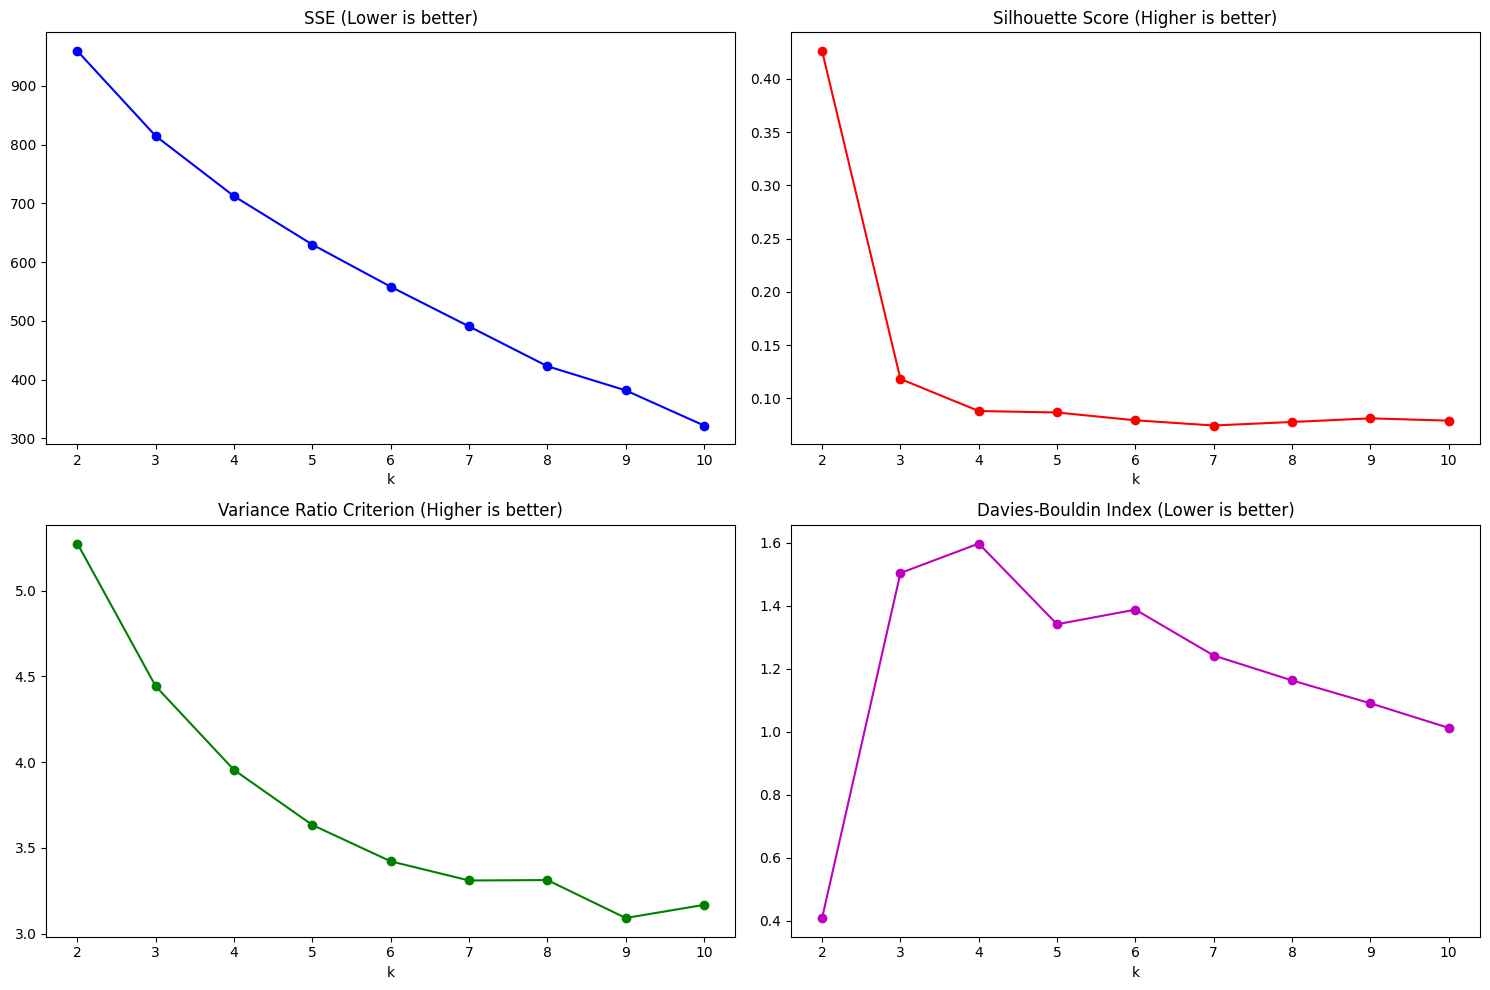

In [6]:
metrics = {
    'sse': [], # Sum of Squared Errors
    'silhouette': [],
    'vrc': [], # Variance Ratio Criterion; Calinski, Harabasz
    'davies_bouldin': []
}
results = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=100)
    labels = kmeans.fit_predict(df)
    results[k] = labels

    metrics['sse'].append(kmeans.inertia_)
    metrics['silhouette'].append(silhouette_score(df.values, labels))
    metrics['vrc'].append(calinski_harabasz_score(df.values, labels))
    metrics['davies_bouldin'].append(davies_bouldin_score(df.values, labels))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
k_range = range(2, 11)

axes[0,0].plot(k_range, metrics['sse'], 'bo-')
axes[0,0].set_title('SSE (Lower is better)')
axes[0,0].set_xlabel('k')

axes[0,1].plot(k_range, metrics['silhouette'], 'ro-')
axes[0,1].set_title('Silhouette Score (Higher is better)')
axes[0,1].set_xlabel('k')

axes[1,0].plot(k_range, metrics['vrc'], 'go-')
axes[1,0].set_title('Variance Ratio Criterion (Higher is better)')
axes[1,0].set_xlabel('k')

axes[1,1].plot(k_range, metrics['davies_bouldin'], 'mo-')
axes[1,1].set_title('Davies-Bouldin Index (Lower is better)')
axes[1,1].set_xlabel('k')

plt.tight_layout()
plt.show()

## Clustering Evaluation
The same evaluation procedure is used again: Overview table, feature importances and a PCA plot.

In [7]:
def cluster_overview(
    original_df: pd.DataFrame,
    cluster_labels: np.ndarray,
    num_cols: List[str],
    cat_cols: List[str],
    bool_cols: List[str],
    feature_importances: Dict[str, float],
) -> pd.DataFrame:
    def num_agg(series):
        res = f"~{series.mean():.2f}"
        if res == "~-0.0":
            return "~0.0"
        return res

    def cat_agg(series):
        vc = series.value_counts(normalize=True)
        if len(vc) >= 1:
            return f"{vc.index[0]} ({vc.iloc[0]:.0%})"
        else:
            return "NA (100%)"

    def bool_agg(series):
        vc = series.value_counts(normalize=True)
        if len(vc) == 1:
            return f"{vc.iloc[0]:.0%} {vc.index[0]}"
        elif len(vc) == 2:
            return f"{vc.iloc[0]:.0%} {vc.index[0]}/{vc.iloc[1]:.0%} {vc.index[1]}"
        else:
            return "100% NA"

    df = original_df.copy(deep=True)
    df["Cluster ID"] = cluster_labels
    
    # Calculate per-cluster aggregations
    df_clusters = pd.concat(
        [
            df[num_cols + ["Cluster ID"]].groupby("Cluster ID").agg(num_agg) if num_cols else pd.DataFrame(),
            df[cat_cols + ["Cluster ID"]].groupby("Cluster ID").agg(cat_agg) if cat_cols else pd.DataFrame(),
            df[bool_cols + ["Cluster ID"]].groupby("Cluster ID").agg(bool_agg) if bool_cols else pd.DataFrame(),
        ],
        axis=1,
    )
    df_clusters = df_clusters.reset_index()
    
    # Calculate overall aggregations for entire dataset
    df_overall = pd.concat(
        [
            df[num_cols].agg(num_agg).to_frame().T if num_cols else pd.DataFrame(),
            df[cat_cols].agg(cat_agg).to_frame().T if cat_cols else pd.DataFrame(),
            df[bool_cols].agg(bool_agg).to_frame().T if bool_cols else pd.DataFrame(),
        ],
        axis=1,
    )
    df_overall["Cluster ID"] = "All Clusters"
    
    # Add member counts
    counts = np.bincount(cluster_labels)
    df_clusters["Members"] = df_clusters.apply(lambda row: counts[int(row["Cluster ID"])], axis=1)
    df_overall["Members"] = len(cluster_labels)
    
    # Format cluster IDs
    df_clusters["Cluster ID"] = df_clusters["Cluster ID"].apply(lambda x: f"Cluster {x}")
    
    # Combine cluster data with overall data
    df_result = pd.concat([df_clusters, df_overall], ignore_index=True)
    
    # Order features by importance
    # Add features not in this dict at the end
    importance_order = list(feature_importances.keys())
    remaining_cols = [col for col in df_result.columns if col not in importance_order and col not in ["Cluster ID", "Members"]]
    df_result = df_result[["Cluster ID", "Members"] + importance_order + remaining_cols]

    return df_result


def feature_importances(
    df: pd.DataFrame,
    labels: np.ndarray
) -> Dict[str, float]:
    classifier = RandomForestClassifier(n_estimators=100)
    classifier.fit(df, labels)
    return dict(
        sorted(
            zip(df.columns, classifier.feature_importances_),
            key=lambda it: it[1],
            reverse=True,
        )
    )



chosen_k = 2
labels = results[chosen_k]

feature_importances_dict = feature_importances(df, labels)
overview_df = cluster_overview(og_df, labels, list(df.columns), [], [], feature_importances_dict)

from IPython.display import display
pd.options.display.max_columns = None
display(overview_df)

,Cluster ID,Members,mfcc_mean_01,mfcc_std_08,mfcc_mean_13,chroma_mean_05,duration,mfcc_mean_05,mfcc_mean_11,mfcc_mean_12,mfcc_std_05,mfcc_std_06,mfcc_std_10,chroma_mean_08,chroma_mean_09,chroma_std_00,chroma_std_02,chroma_std_05,n_beats,mfcc_mean_02,mfcc_mean_03,mfcc_mean_04,mfcc_mean_09,mfcc_std_07,mfcc_std_09,chroma_mean_02,chroma_mean_10,chroma_std_01,chroma_std_03,chroma_std_04,chroma_std_06,chroma_std_08,chroma_std_09,chroma_std_10,chroma_std_11,chroma_entropy,onset_std,tempo,mfcc_mean_06,mfcc_mean_07,mfcc_mean_08,mfcc_mean_10,mfcc_std_01,mfcc_std_02,mfcc_std_03,mfcc_std_04,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_var_mean,chroma_mean_00,chroma_mean_01,chroma_mean_03,chroma_mean_04,chroma_mean_06,chroma_mean_07,chroma_mean_11,chroma_std_07,chroma_max_frac,onset_mean,onset_p95,onset_peakiness,onset_diff_mean,onset_diff_p95
0,Cluster 0,1,~-171.76,~4.85,~17.28,~0.50,~53.96,~-8.10,~3.57,~-0.90,~7.63,~4.71,~4.34,~0.53,~0.61,~0.11,~0.13,~0.12,~96.00,~193.51,~-120.92,~-15.78,~-15.88,~3.12,~4.17,~0.51,~0.55,~0.11,~0.12,~0.11,~0.12,~0.14,~0.14,~0.13,~0.10,~2.48,~0.23,~107.67,~-41.59,~9.92,~-8.54,~18.13,~35.42,~16.33,~14.90,~7.16,~4.92,~2.88,~2.87,~152.71,~0.49,~0.48,~0.48,~0.45,~0.47,~0.49,~0.48,~0.14,~0.10,~0.94,~1.27,~1.35,~0.25,~0.54
1,Cluster 1,19,~-52.50,~7.60,~-0.18,~0.37,~193.20,~9.53,~-2.57,~3.65,~12.09,~9.20,~6.89,~0.37,~0.41,~0.21,~0.20,~0.19,~376.32,~88.99,~0.12,~19.23,~-4.03,~8.16,~7.20,~0.40,~0.42,~0.18,~0.18,~0.21,~0.18,~0.18,~0.21,~0.20,~0.20,~2.47,~0.30,~119.15,~6.78,~-1.62,~4.61,~4.67,~61.48,~21.39,~17.79,~12.91,~6.26,~6.13,~5.76,~464.46,~0.44,~0.38,~0.40,~0.42,~0.36,~0.37,~0.44,~0.19,~0.11,~1.10,~1.61,~1.46,~0.23,~0.66
2,All Clusters,20,~-58.46,~7.46,~0.69,~0.37,~186.24,~8.65,~-2.26,~3.43,~11.87,~8.97,~6.76,~0.38,~0.42,~0.21,~0.19,~0.19,~362.30,~94.22,~-5.94,~17.48,~-4.63,~7.90,~7.05,~0.40,~0.42,~0.18,~0.18,~0.21,~0.18,~0.18,~0.20,~0.19,~0.20,~2.47,~0.30,~118.57,~4.36,~-1.04,~3.95,~5.34,~60.17,~21.14,~17.64,~12.62,~6.20,~5.97,~5.61,~448.87,~0.44,~0.39,~0.40,~0.42,~0.36,~0.38,~0.44,~0.19,~0.11,~1.09,~1.59,~1.45,~0.24,~0.66


In [8]:
print(overview_df.iloc[:, :5].to_latex(index=False))

\begin{tabular}{lrlll}
\toprule
Cluster ID & Members & mfcc_mean_01 & mfcc_std_08 & mfcc_mean_13 \\
\midrule
Cluster 0 & 1 & ~-171.76 & ~4.85 & ~17.28 \\
Cluster 1 & 19 & ~-52.50 & ~7.60 & ~-0.18 \\
All Clusters & 20 & ~-58.46 & ~7.46 & ~0.69 \\
\bottomrule
\end{tabular}



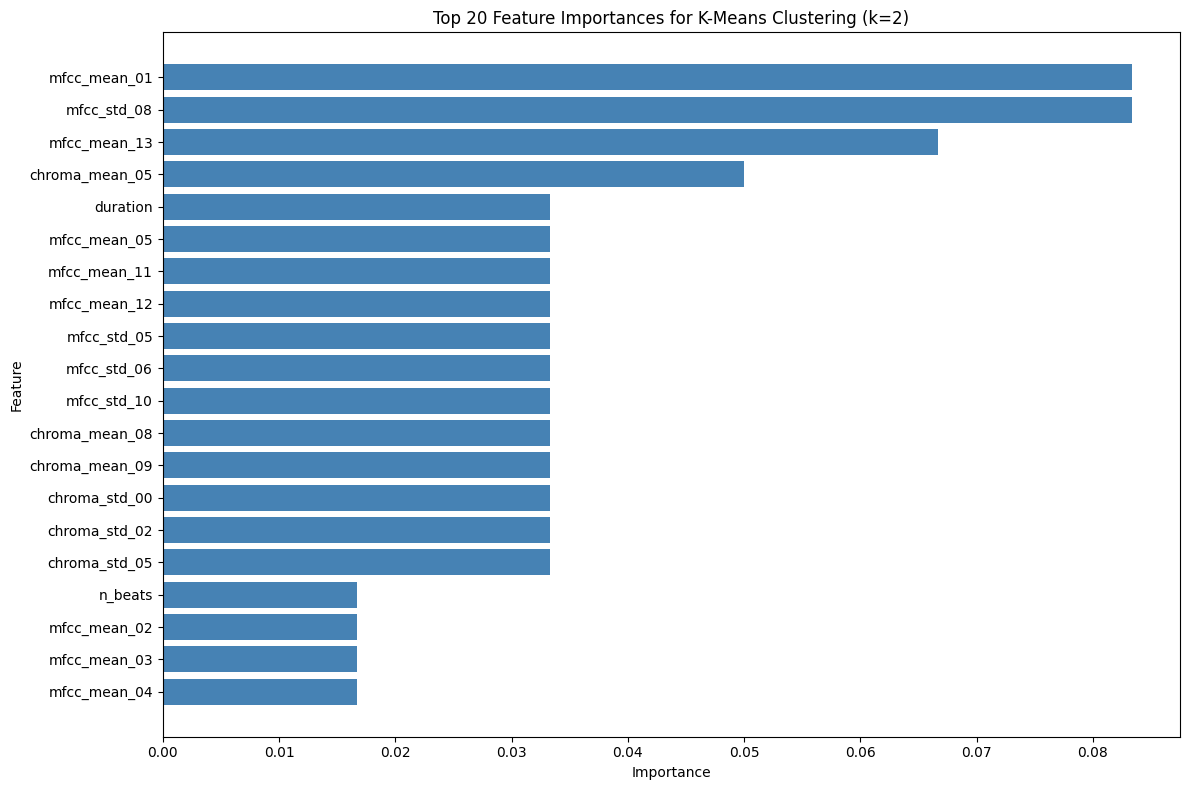

In [9]:
top_n = 20
top_features = list(feature_importances_dict.items())[:top_n]
features, importances = zip(*top_features)

plt.figure(figsize=(12, 8))
plt.barh(range(len(features)), importances, color='steelblue')
plt.yticks(range(len(features)), features)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importances for K-Means Clustering (k={chosen_k})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

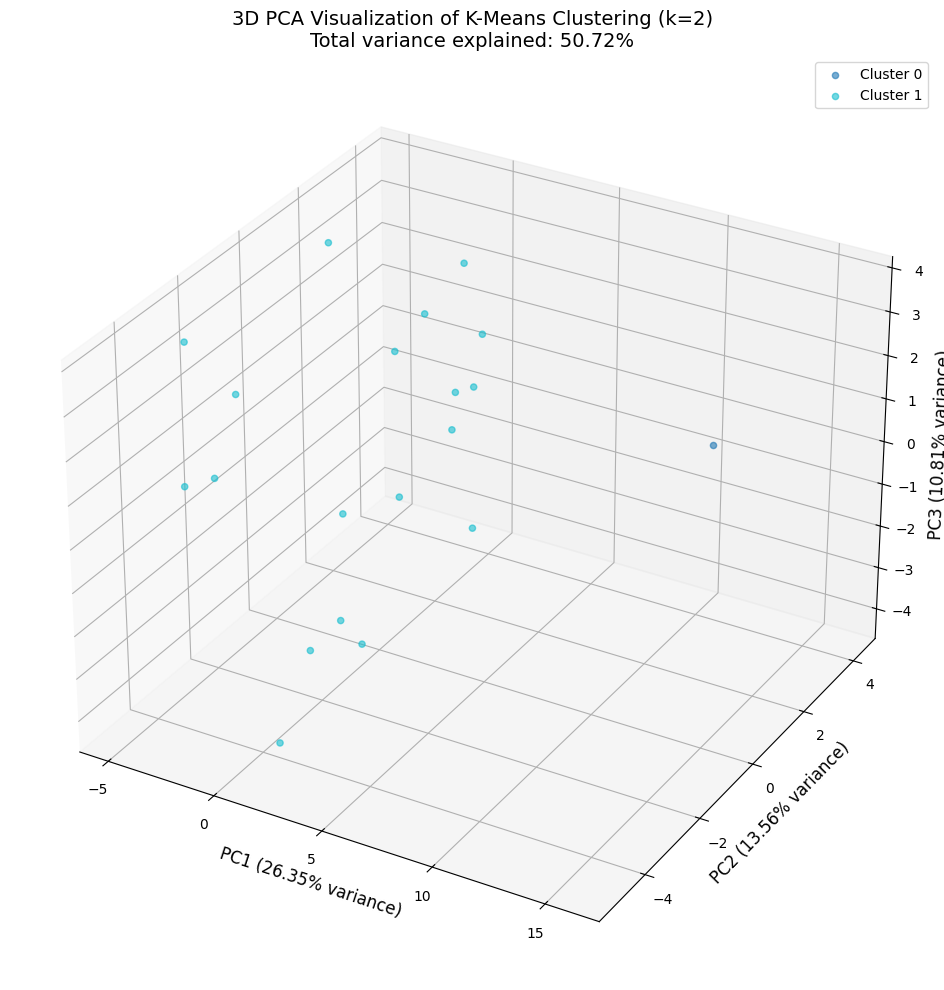

Explained variance by component: [0.26351771 0.13557348 0.10813168]
Total explained variance: 50.72%


In [10]:
# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
pca_features = pca.fit_transform(df)

# Create 3D scatter plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Define colors for each cluster
colors = plt.cm.tab10(np.linspace(0, 1, chosen_k))

# Plot each cluster with a different color
for cluster_id in range(chosen_k):
    cluster_mask = labels == cluster_id
    ax.scatter(
        pca_features[cluster_mask, 0],
        pca_features[cluster_mask, 1],
        pca_features[cluster_mask, 2],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=20
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)', fontsize=12)
ax.set_title(f'3D PCA Visualization of K-Means Clustering (k={chosen_k})\nTotal variance explained: {pca.explained_variance_ratio_.sum():.2%}', fontsize=14)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")